In [7]:
import pandas as pd

df = pd.read_csv("Women-Safety-AI/data/twitter_labeled.csv")

In [8]:
X_text = df["Clean_Tweet"]

y = df["Sentiment"]

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_features = tfidf.fit_transform(X_text)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
print(X_train.shape)
print(X_test.shape)

(3685, 5000)
(922, 5000)


In [12]:
#Navie Bayes

In [13]:
from sklearn.naive_bayes import MultinomialNB

In [14]:
nb_model = MultinomialNB()

In [50]:
start = time.time()

svm_model.fit(X_train, y_train)

end = time.time()

nb_training_time = end - start

print("Training Time:",
      round(svm_training_time,3),
      "seconds")

Training Time: 0.081 seconds


In [49]:
start = time.time()

y_pred_svm = svm_model.predict(X_test)

end = time.time()

nb_prediction_time = end - start

print("Prediction Time:",
      round(svm_prediction_time,3),
      "seconds")

Prediction Time: 0.001 seconds


In [15]:
nb_model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [16]:
y_pred_nb = nb_model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", round(accuracy*100,2), "%")

Naive Bayes Accuracy: 95.23 %


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

    Negative       0.95      0.99      0.97       688
     Neutral       0.97      0.90      0.93        78
    Positive       0.95      0.83      0.88       156

    accuracy                           0.95       922
   macro avg       0.96      0.90      0.93       922
weighted avg       0.95      0.95      0.95       922



In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_nb)

print(cm)

[[679   2   7]
 [  8  70   0]
 [ 27   0 129]]


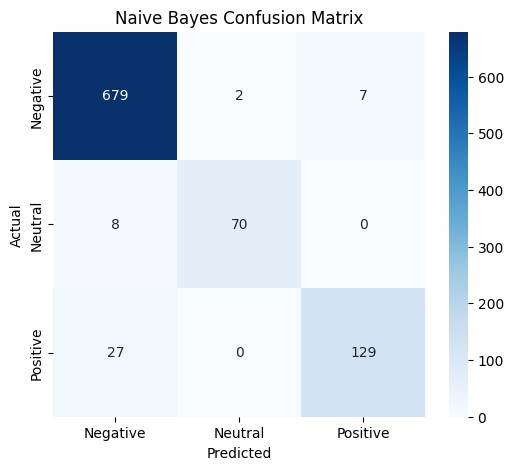

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=nb_model.classes_,
    yticklabels=nb_model.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [21]:
results = []

results.append({
    "Model": "Naive Bayes",
    "Accuracy": round(accuracy*100,2)
})

results

[{'Model': 'Naive Bayes', 'Accuracy': 95.23}]

In [22]:
import pandas as pd

results = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
])

results.loc[len(results)] = [
    "Naive Bayes",
    accuracy_score(y_test, y_pred_nb),
    0.95,
    0.95,
    0.95
]

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.952278,0.95,0.95,0.95


In [23]:
#Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression
import time

In [25]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [26]:
start = time.time()

lr_model.fit(X_train, y_train)

end = time.time()

lr_training_time = end - start

print("Training Time:", round(lr_training_time,3), "seconds")

Training Time: 0.516 seconds


In [33]:
start = time.time()

y_pred_lr = lr_model.predict(X_test)

end = time.time()

lr_prediction_time = end - start

print("Prediction Time:", round(lr_prediction_time,3), "seconds")

Prediction Time: 0.002 seconds


In [28]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:",
      round(lr_accuracy*100,2), "%")

Logistic Regression Accuracy: 96.42 %


In [29]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_lr
))

              precision    recall  f1-score   support

    Negative       0.96      1.00      0.98       688
     Neutral       1.00      0.90      0.95        78
    Positive       0.99      0.85      0.91       156

    accuracy                           0.96       922
   macro avg       0.98      0.91      0.95       922
weighted avg       0.97      0.96      0.96       922



In [30]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

print(cm_lr)

[[687   0   1]
 [  8  70   0]
 [ 24   0 132]]


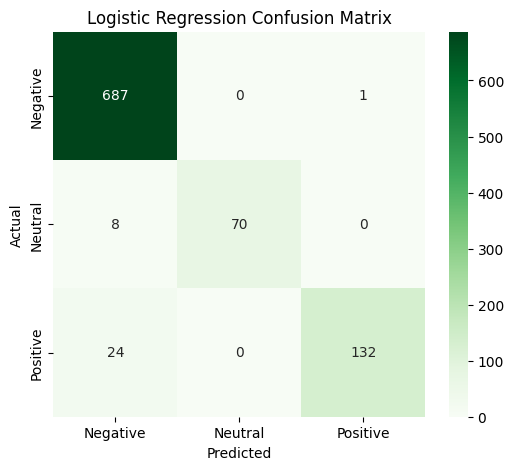

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=lr_model.classes_,
    yticklabels=lr_model.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [32]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred_lr,
    average="weighted"
)

results.loc[len(results)] = [
    "Logistic Regression",
    round(lr_accuracy*100,2),
    round(precision*100,2),
    round(recall*100,2),
    round(f1*100,2)
]

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.952278,0.95,0.95,0.95
1,Logistic Regression,96.420000,96.55,96.42,96.33


In [34]:
#Linear SVM

In [35]:
from sklearn.svm import LinearSVC
import time

In [36]:
svm_model = LinearSVC(random_state=42)

In [37]:
start = time.time()

svm_model.fit(X_train, y_train)

end = time.time()

svm_training_time = end - start

print("Training Time:",
      round(svm_training_time,3),
      "seconds")

Training Time: 0.081 seconds


In [38]:
start = time.time()

y_pred_svm = svm_model.predict(X_test)

end = time.time()

svm_prediction_time = end - start

print("Prediction Time:",
      round(svm_prediction_time,3),
      "seconds")

Prediction Time: 0.001 seconds


In [39]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

print("Linear SVM Accuracy:",
      round(svm_accuracy*100,2),
      "%")

Linear SVM Accuracy: 97.4 %


In [40]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_svm
))

              precision    recall  f1-score   support

    Negative       0.97      0.99      0.98       688
     Neutral       0.97      0.91      0.94        78
    Positive       0.99      0.92      0.95       156

    accuracy                           0.97       922
   macro avg       0.98      0.94      0.96       922
weighted avg       0.97      0.97      0.97       922



In [41]:
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

print(cm_svm)

[[684   2   2]
 [  7  71   0]
 [ 13   0 143]]


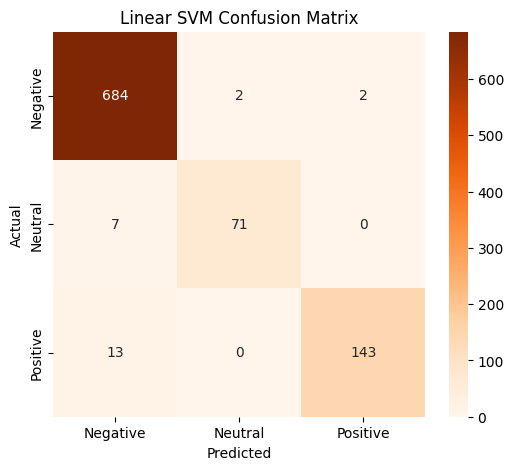

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)

plt.title("Linear SVM Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [43]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred_svm,
    average="weighted"
)

results.loc[len(results)] = [
    "Linear SVM",
    round(svm_accuracy*100,2),
    round(precision*100,2),
    round(recall*100,2),
    round(f1*100,2)
]

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.952278,0.95,0.95,0.95
1,Logistic Regression,96.420000,96.55,96.42,96.33
2,Linear SVM,97.400000,97.41,97.40,97.37


In [52]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        95.23,
        96.42,
        97.40
    ],
    "Train Time (s)": [
        nb_training_time,
        lr_training_time,
        svm_training_time
    ],
    "Prediction Time (s)": [
        nb_prediction_time,
        lr_prediction_time,
        svm_prediction_time
    ]
})

comparison

,Model,Accuracy,Train Time (s),Prediction Time (s)
0,Naive Bayes,95.23,0.054756,0.001686
1,Logistic Regression,96.42,0.516108,0.001573
2,Linear SVM,97.40,0.080601,0.001020


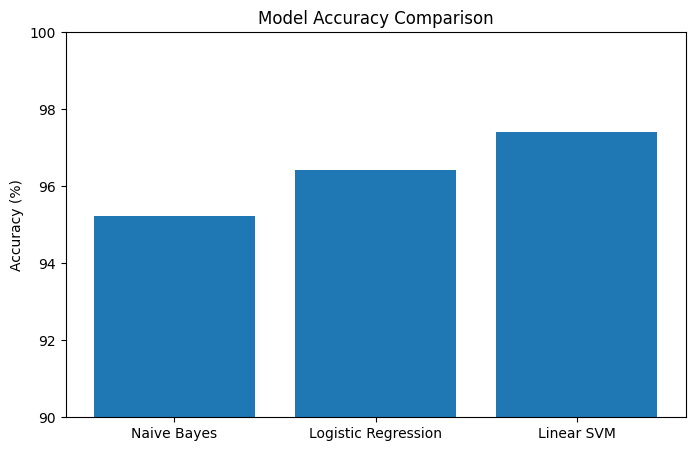

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(comparison["Model"],
        comparison["Accuracy"])

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy (%)")

plt.ylim(90,100)

plt.show()

In [54]:
#Random Forest

In [55]:
from sklearn.ensemble import RandomForestClassifier
import time

In [56]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [57]:
start = time.time()

rf_model.fit(X_train, y_train)

end = time.time()

rf_training_time = end - start

print("Training Time:", round(rf_training_time,3), "seconds")

Training Time: 0.747 seconds


In [59]:
start = time.time()

y_pred_rf = rf_model.predict(X_test)

end = time.time()

rf_prediction_time = end - start

print("Prediction Time:", round(rf_prediction_time,3), "seconds")

Prediction Time: 0.086 seconds


In [60]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:",
      round(rf_accuracy*100,2),
      "%")

Random Forest Accuracy: 97.07 %


In [61]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

    Negative       0.97      1.00      0.98       688
     Neutral       0.97      0.91      0.94        78
    Positive       0.99      0.89      0.94       156

    accuracy                           0.97       922
   macro avg       0.98      0.93      0.95       922
weighted avg       0.97      0.97      0.97       922



In [62]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print(cm_rf)

[[685   2   1]
 [  7  71   0]
 [ 17   0 139]]


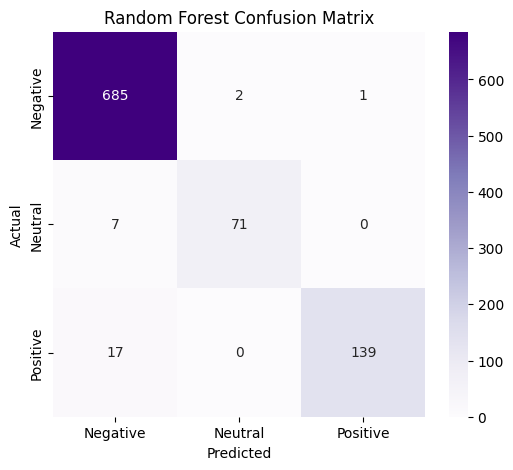

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [64]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM",
        "Random Forest"
    ],

    "Accuracy (%)": [
        95.23,
        96.42,
        97.40,
        round(rf_accuracy*100,2)
    ]
})

comparison

,Model,Accuracy (%)
0,Naive Bayes,95.23
1,Logistic Regression,96.42
2,Linear SVM,97.40
3,Random Forest,97.07


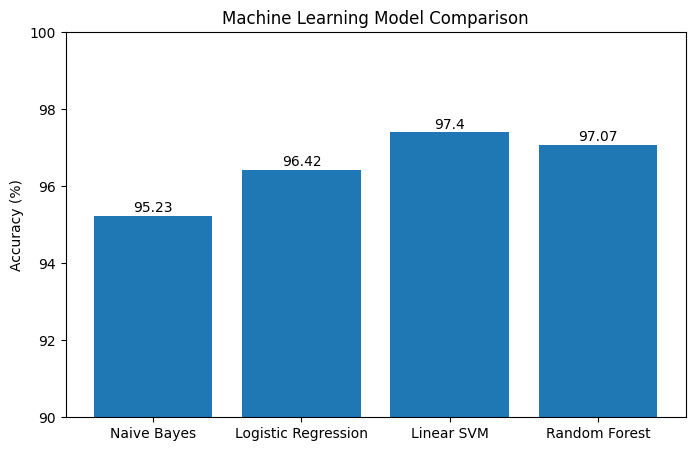

In [65]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy (%)"]
)

plt.title("Machine Learning Model Comparison")

plt.ylabel("Accuracy (%)")

plt.ylim(90,100)

for i,v in enumerate(comparison["Accuracy (%)"]):
    plt.text(i,v+0.1,str(v),ha="center")

plt.show()

In [66]:
import joblib

joblib.dump(
    svm_model,
    "Women-Safety-AI/models/svm_model.pkl"
)

['Women-Safety-AI/models/svm_model.pkl']

In [67]:
joblib.dump(
    tfidf,
    "Women-Safety-AI/models/tfidf_vectorizer.pkl"
)

['Women-Safety-AI/models/tfidf_vectorizer.pkl']

In [69]:
import os

print(os.listdir("Women-Safety-AI/models"))

['svm_model.pkl', 'tfidf_vectorizer.pkl']
